In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
grid_size = 5

grid = np.zeros((grid_size, grid_size))

goal = (4,4)

grid[goal] = 10

print(grid)

[[ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. 10.]]


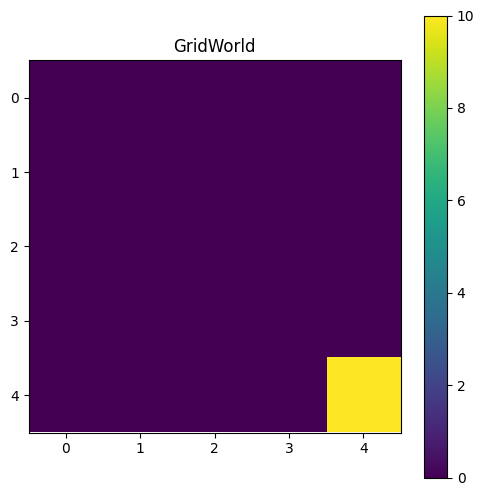

In [4]:
plt.figure(figsize=(6,6))

plt.imshow(grid)

plt.colorbar()

plt.title("GridWorld")

plt.show()

In [5]:
V = np.zeros((grid_size, grid_size))

print(V)

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [6]:
actions = [
    (-1,0),  # Up
    (1,0),   # Down
    (0,-1),  # Left
    (0,1)    # Right
]

print(actions)

[(-1, 0), (1, 0), (0, -1), (0, 1)]


In [7]:
gamma = 0.9

def get_next_state(i,j,action):

    ni = i + action[0]
    nj = j + action[1]

    ni = max(0,min(grid_size-1,ni))
    nj = max(0,min(grid_size-1,nj))

    return ni,nj

In [8]:
iterations = 100

for _ in range(iterations):

    new_V = V.copy()

    for i in range(grid_size):

        for j in range(grid_size):

            if (i,j) == goal:
                continue

            values = []

            for action in actions:

                ni,nj = get_next_state(i,j,action)

                reward = 10 if (ni,nj)==goal else -1

                values.append(
                    reward + gamma * V[ni,nj]
                )

            new_V[i,j] = max(values)

    V = new_V

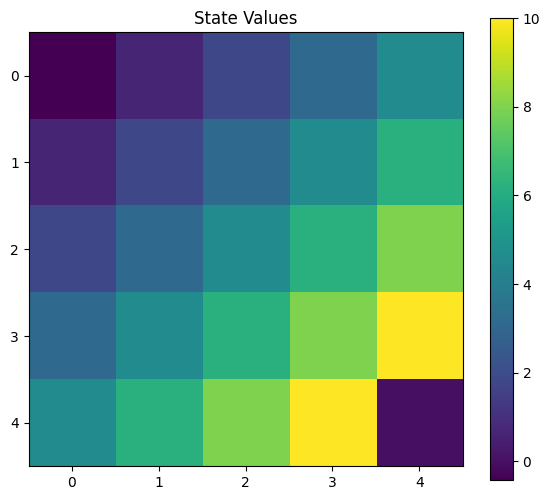

In [9]:
plt.figure(figsize=(7,6))

plt.imshow(V)

plt.colorbar()

plt.title("State Values")

plt.show()

In [10]:
policy = np.full((grid_size,grid_size)," ")

arrows = ["↑","↓","←","→"]

for i in range(grid_size):

    for j in range(grid_size):

        if (i,j)==goal:

            policy[i,j]="G"

            continue

        values=[]

        for action in actions:

            ni,nj = get_next_state(i,j,action)

            values.append(V[ni,nj])

        best_action = np.argmax(values)

        policy[i,j]=arrows[best_action]

In [11]:
for row in policy:

    print(" ".join(row))

↓ ↓ ↓ ↓ ↓
↓ ↓ ↓ ↓ ↓
↓ ↓ ↓ ↓ ↓
↓ ↓ ↓ ↓ →
→ → → ↓ G


In [ ]:
state = (0,0)

path = [state]

while state != goal:

    i,j = state

    values=[]

    for action in actions:

        ni,nj = get_next_state(i,j,action)

        values.append(V[ni,nj])

    best = np.argmax(values)

    state = get_next_state(i,j,actions[best])

    path.append(state)

print(path)

In [ ]:
grid_path = np.zeros((grid_size,grid_size))

for x,y in path:

    grid_path[x,y] = 1

grid_path[goal] = 5

plt.figure(figsize=(6,6))

plt.imshow(grid_path)

plt.colorbar()

plt.title("Optimal Path")

plt.show()

In [ ]:
print("Start State :", (0,0))
print("Goal State  :", goal)
print("Path Length :", len(path))